# 15 — CPT bake-off: train all inits @100k & find the SALT sweet spot

Train **every `trung_*` init arm** under one *identical* 100k-doc CPT budget, then compare them on
**loss / perplexity** (overlaid curves) and **one downstream task** (UIT-VSFC sentiment) at an
**early (~25%) snapshot** and the **final** model.

**Why this design.** A good init (SALT) should reach a given quality with *less* data — the paper's
resource-saving claim. So the interesting signal is the **gap to the random controls as a function of
budget**: widest early, possibly closing by 100k. If every arm has converged well before 100k and the
gap is gone, 100k is *past* the sweet spot (the body just learned from data). The step-matched eval
curves are a free budget sweep; the early-vs-final downstream deltas test the claim on real task perf.

**Matched-budget rules (what makes the comparison fair):** same data slice, seed, hyperparameters for
every arm; **no early stopping, no load_best** so all arms stop at the same step. Heavy lifting lives in
`salt3_bakeoff.py` + `salt3_downstream_probe.py`; this notebook just orchestrates.

> **Runtime/disk:** ~3–4 h CPT + ~1–2 h downstream on an **A100**; ~15 GB on Drive for 8×(final+early)
> snapshots. Every stage **skips work already on disk**, so a disconnect just means *Run all* again.

In [1]:
%%capture
!pip install -U transformers accelerate datasets safetensors sentencepiece tokenizers pandas tqdm huggingface_hub scikit-learn matplotlib evaluate

In [2]:
import sys, importlib
from pathlib import Path
import torch

try:
    from google.colab import drive; drive.mount('/content/drive')
except Exception as e:
    print('Drive mount skipped:', e)

PROJECT_ROOT = Path('/content/drive/MyDrive/SALT3') if Path('/content/drive/MyDrive').exists() else Path.cwd() / 'SALT3'
sys.path.insert(0, str(PROJECT_ROOT / 'code')); sys.path.insert(0, '/content')

import salt3_common as sc; importlib.reload(sc)
import salt3_bakeoff as bk; importlib.reload(bk)
import salt3_downstream_probe as dp; importlib.reload(dp)
from salt3_common import configure_environment, set_seed, ensure_dir, tokenizer_fingerprint, make_mlm_datasets

configure_environment(); set_seed(42)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
assert DEVICE == 'cuda', 'bake-off needs the GPU runtime (use the A100); CPU forward is too slow for 8 arms'
import transformers
print('torch', torch.__version__, '| transformers', transformers.__version__, '| device', DEVICE)

Mounted at /content/drive
torch 2.11.0+cu128 | transformers 5.12.0 | device cuda


## 1. Configure the bake-off

In [3]:
INIT_ROOT    = PROJECT_ROOT / 'init'
ARM_PATTERN  = 'trung_*'               # all matched arms (SALT variants + random controls)
RUNS_ROOT    = ensure_dir(PROJECT_ROOT / 'runs' / 'bakeoff100k')
COMPARE_DIR  = ensure_dir(RUNS_ROOT / '_compare')
DATASET_CACHE = ensure_dir(PROJECT_ROOT / 'datasets')
EARLY_FRAC   = 0.25                    # early snapshot ≈ 25k docs of the 100k budget
FORCE_CPT    = False                   # True = retrain arms even if final_model exists

# Identical for EVERY arm. 100k docs ≈ ~93k chunks ≈ ~182 optimizer steps at eff. batch 512.
DATA_CONFIG = {
    'num_examples': 100_000, 'max_seq_len': 1024, 'num_chunks': None,
    'eval_ratio': 0.02, 'mlm_probability': 0.20, 'seed': 42,
}
TRAIN_CONFIG = {
    'num_train_epochs': 1, 'max_steps': -1,
    'per_device_train_batch_size': 32, 'per_device_eval_batch_size': 32,
    'gradient_accumulation_steps': 16,            # effective batch 512
    'learning_rate': 1e-4, 'adam_beta2': 0.95, 'weight_decay': 0.01, 'warmup_ratio': 0.05,
    'logging_steps': 10, 'eval_steps': 15, 'save_steps': 15, 'save_total_limit': 3,
    # NOTE: no early_stopping / load_best -> every arm runs the full matched budget.
}

# Downstream probe (light; "just a few training")
DOWNSTREAM_SEEDS = [42, 123]
FT_KWARGS = dict(lr=2e-5, max_epochs=5, batch_size=16, max_len=256, patience=2)
RANDOM_ARMS = ('trung_random_meannorm', 'trung_naive_random_zerobias')
RESULTS_JSONL = RUNS_ROOT / 'downstream_results.jsonl'
print('runs root :', RUNS_ROOT)
print('compare   :', COMPARE_DIR)

runs root : /content/drive/MyDrive/SALT3/runs/bakeoff100k
compare   : /content/drive/MyDrive/SALT3/runs/bakeoff100k/_compare


## 2. Discover arms

In [4]:
ARMS = bk.discover_arms(INIT_ROOT, ARM_PATTERN)
assert ARMS, f'no arms matching {ARM_PATTERN!r} with a model.safetensors under {INIT_ROOT}'
import json as _json
print(f'{len(ARMS)} arms:')
for name, mdir in ARMS:
    cfg = mdir.parent / 'salt_config.json'
    dec = _json.loads(cfg.read_text()).get('decoder_init', '?') if cfg.exists() else '?'
    print(f'  {name:34s} decoder_init={dec}')

8 arms:
  trung_naive_random_zerobias        decoder_init=random_N0_0.02
  trung_random_meannorm              decoder_init=global_emb_to_decoder_map
  trung_salt_decpertoken             decoder_init=projected_from_neobert_decoder
  trung_salt_decscale05              decoder_init=global_emb_to_decoder_map
  trung_salt_decscale10              decoder_init=global_emb_to_decoder_map
  trung_salt_dectied                 decoder_init=tied_to_embeddings
  trung_salt_freezealigned           decoder_init=global_emb_to_decoder_map
  trung_salt_globalmap_freqbias      decoder_init=global_emb_to_decoder_map


## 3. Build the matched dataset once

Every arm uses the *same* pruned NeoBERT tokenizer, so the tokenized 100k cache is shared. We assert
that here — if any arm's tokenizer differs, the data would not be matched and the comparison is void.
First build streams + tokenizes CulturaX (slow, one-time); afterwards it loads from the Drive cache.

In [ ]:
from transformers import AutoTokenizer
fps = {}
for name, mdir in ARMS:
    tk = AutoTokenizer.from_pretrained(mdir, trust_remote_code=True)
    fps[name] = tokenizer_fingerprint(tk)['sha256']   # dict -> use hashable digest
uniq = set(fps.values())
print('tokenizer fingerprints:', len(uniq), 'unique')
assert len(uniq) == 1, f'arms use different tokenizers -> data NOT matched: {fps}'

tok0 = AutoTokenizer.from_pretrained(ARMS[0][1], trust_remote_code=True)
train_ds, eval_ds = make_mlm_datasets(
    tokenizer=tok0, cache_dir=DATASET_CACHE,
    num_examples=DATA_CONFIG['num_examples'], max_seq_len=DATA_CONFIG['max_seq_len'],
    num_chunks=DATA_CONFIG['num_chunks'], eval_ratio=DATA_CONFIG['eval_ratio'], seed=DATA_CONFIG['seed'])
print('cache ready:', len(train_ds), 'train /', len(eval_ds), 'eval chunks')
del train_ds, eval_ds

tokenizer fingerprints: 1 unique
Tokenizer fingerprint: 3487ef147c62 (DebertaV2Tokenizer, vocab=30522)
Dataset cache key    : culturax_vi_100000_seq1024_tok3487ef147c62_ev0.02_s42_docsplit
Streaming 100,000 CulturaX-vi docs (this is the slow part, ~1 hr for 3M)...
  Result will be cached to /content/drive/MyDrive/SALT3/datasets/culturax_vi_100000_seq1024_tok3487ef147c62_ev0.02_s42_docsplit for instant reload next time.


README.md:   0%|          | 0.00/32.6k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/90 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

      50,000 docs ->     47,481 chunks
     100,000 docs ->     94,802 chunks
  Total: 100,000 docs -> 94,802 chunks of 1024 tokens


...

Filter:   0%|          | 0/94802 [00:00<?, ? examples/s]

  Saving cache to /content/drive/MyDrive/SALT3/datasets/culturax_vi_100000_seq1024_tok3487ef147c62_ev0.02_s42_docsplit ...


Saving the dataset (0/1 shards):   0%|          | 0/92885 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1917 [00:00<?, ? examples/s]

  Cache saved (92,885 train + 1,917 eval)
  Using 92,885 train + 1,917 eval chunks
cache ready: 92885 train / 1917 eval chunks


## 4. CPT every arm (matched budget)

One pass per arm. Arms whose `final_model` already exists are skipped, so re-running after a disconnect
resumes the bake-off. Each arm saves: dense metrics jsonl, an `early_25pct/` snapshot, and `final_model/`.

In [ ]:
arm_results = []
for name, mdir in ARMS:
    print('='*70, f'\nCPT arm: {name}')
    res = bk.run_cpt_arm(
        name, mdir, RUNS_ROOT, DATASET_CACHE,
        data_cfg=DATA_CONFIG, train_cfg=TRAIN_CONFIG,
        early_frac=EARLY_FRAC, save_early=True, device=DEVICE, force=FORCE_CPT)
    arm_results.append(res)
    print('   ->', res['status'])
print('\nall arms done:', [(r['arm'], r['status']) for r in arm_results])

CPT arm: trung_naive_random_zerobias
Tokenizer fingerprint: 3487ef147c62 (DebertaV2Tokenizer, vocab=30522)
Dataset cache key    : culturax_vi_100000_seq1024_tok3487ef147c62_ev0.02_s42_docsplit
Loading cached dataset from /content/drive/MyDrive/SALT3/datasets/culturax_vi_100000_seq1024_tok3487ef147c62_ev0.02_s42_docsplit ...
  Using 92,885 train + 1,917 eval chunks
  ✓ load_model_safe: all 172 keys loaded successfully


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training Loss,Validation Loss,Step
No log,16.250645,0


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


[trung_naive_random_zerobias] pre-CPT eval: {'eval_loss': 16.25064468383789, 'eval_perplexity': 11417349.972713372}
Resume mode selected, but no trainer checkpoint exists yet; starting this run from its configured base model.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Step
3.051736,3.084833,182


[trung_salt_globalmap_freqbias] post-CPT eval: {'eval_loss': 3.0848331451416016, 'eval_perplexity': 21.863818453375945} (steps=182)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   -> trained

all arms done: [('trung_naive_random_zerobias', 'trained'), ('trung_random_meannorm', 'trained'), ('trung_salt_decpertoken', 'trained'), ('trung_salt_decscale05', 'trained'), ('trung_salt_decscale10', 'trained'), ('trung_salt_dectied', 'trained'), ('trung_salt_freezealigned', 'trained'), ('trung_salt_globalmap_freqbias', 'trained')]


## 5. Compare training curves (step-matched = budget-matched)

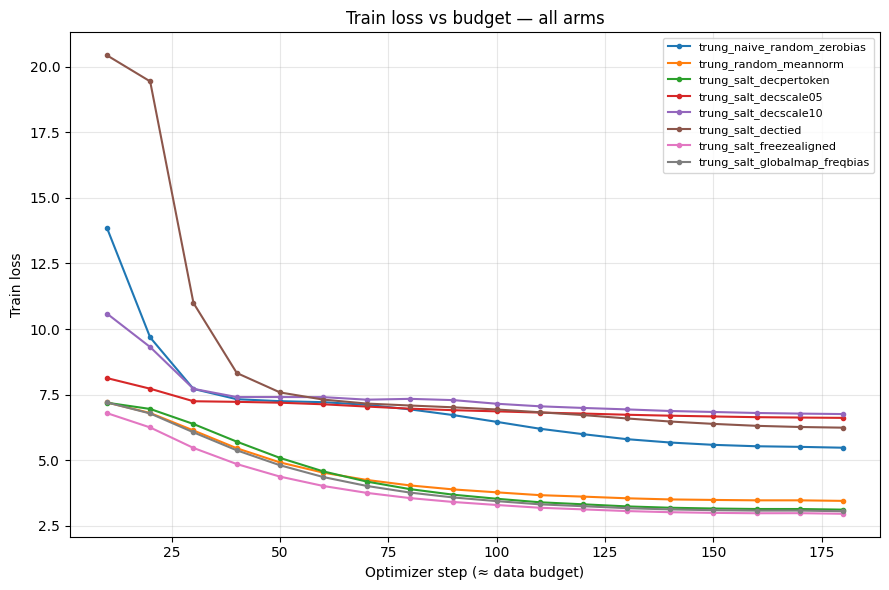

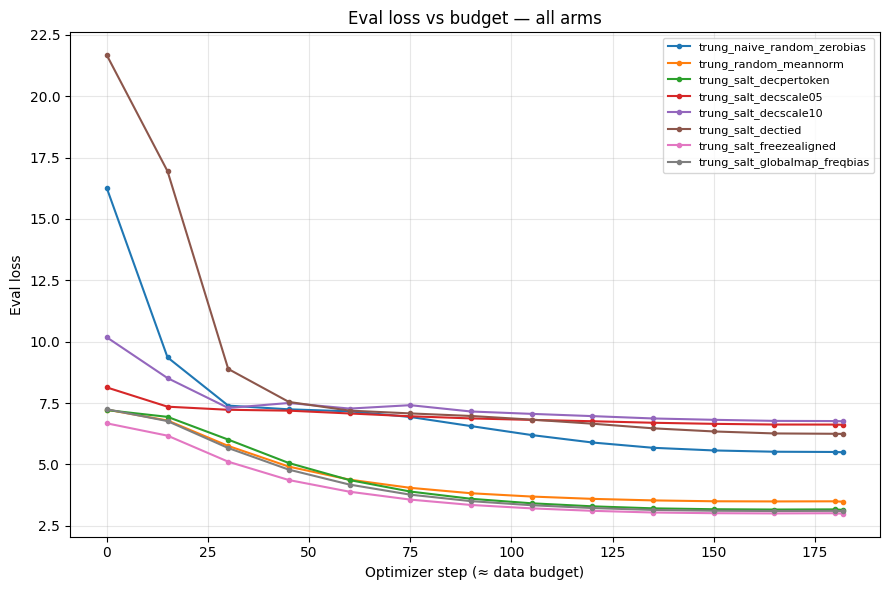

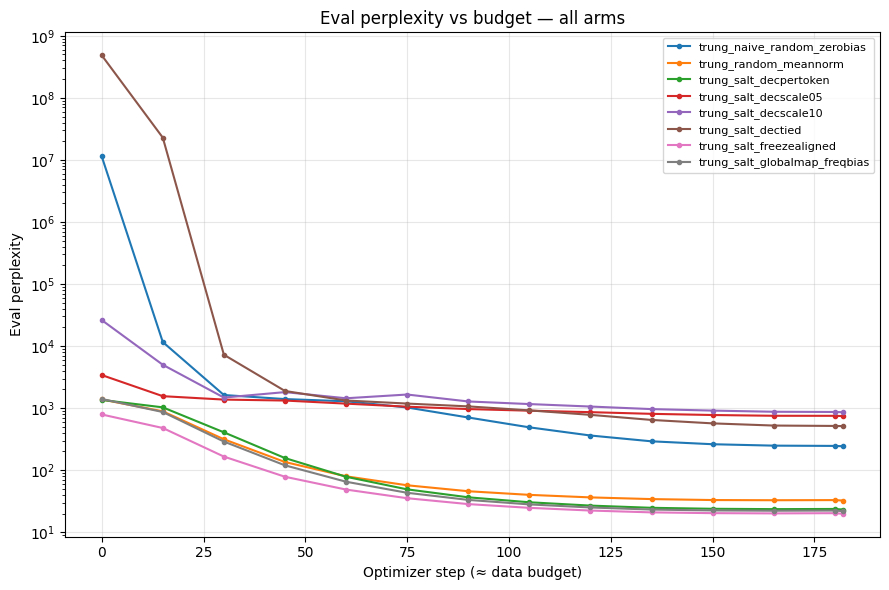

saved overlays: ['/content/drive/MyDrive/SALT3/runs/bakeoff100k/_compare/train_loss_overlay.png', '/content/drive/MyDrive/SALT3/runs/bakeoff100k/_compare/eval_loss_overlay.png', '/content/drive/MyDrive/SALT3/runs/bakeoff100k/_compare/eval_ppl_overlay.png']


In [ ]:
arm_metrics = {r['arm']: r['metrics_path'] for r in arm_results if Path(r['metrics_path']).exists()}
paths = bk.overlay_comparison_curves(arm_metrics, COMPARE_DIR)
print('saved overlays:', [str(p) for p in paths])

## 6. Downstream sweet-spot probe — UIT-VSFC

Fine-tune each arm's **early (~25%)** and **final** checkpoint on VSFC sentiment (light, fixed LR,
2 seeds). Records test accuracy + F1. Already-done (arm, checkpoint, seed) rows are skipped.

In [ ]:
vsfc = dp.load_vsfc()
print('VSFC splits:', {k: len(v) for k, v in vsfc.items()})
results = dp.run_downstream_probe(
    arm_results, vsfc, RESULTS_JSONL,
    num_labels=3, seeds=DOWNSTREAM_SEEDS, checkpoints=('final', 'early'),
    device=DEVICE, **FT_KWARGS)
print('downstream rows:', len(results))

train.json:   0%|          | 0.00/2.69M [00:00<?, ?B/s]

valid.json:   0%|          | 0.00/367k [00:00<?, ?B/s]

test.json:   0%|          | 0.00/744k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11426 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1583 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/3166 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,0.269278,0.363389,0.901453,0.887470
2,0.256199,0.263355,0.929248,0.928034
3,0.116468,0.284473,0.933039,0.931601
4,0.047330,0.390571,0.926721,0.925504
5,0.036566,0.421925,0.929248,0.928235


[transformers] early stopping required metric_for_best_model, but did not find eval_f1_weighted so early stopping is disabled


Training Loss,Validation Loss,Epoch,Accuracy,F1 Weighted
0.036566,0.414159,5,0.903348,0.897758


    -> {'arm': 'trung_salt_globalmap_freqbias', 'checkpoint': 'early', 'seed': 123, 'accuracy': 0.903348073278585, 'f1_weighted': 0.8977577244967619}
downstream rows: 32


saved /content/drive/MyDrive/SALT3/runs/bakeoff100k/_compare/downstream_summary.csv


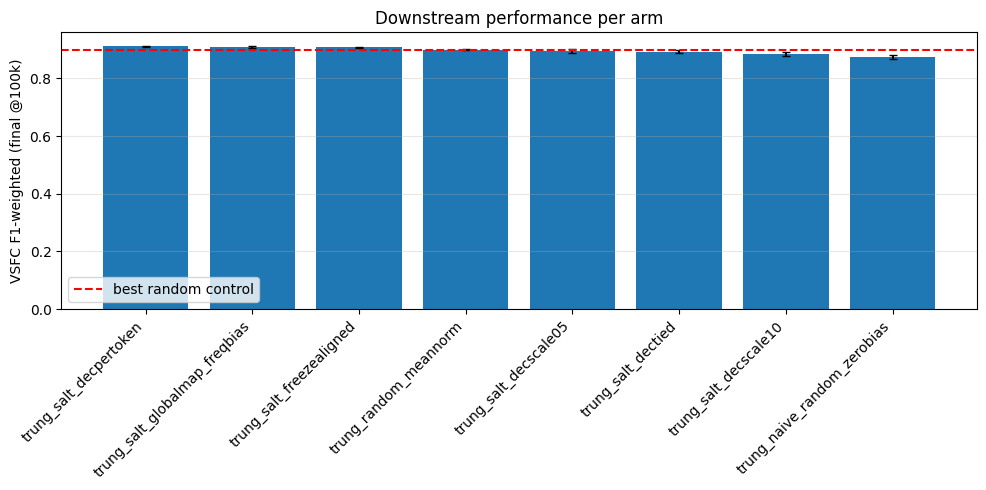

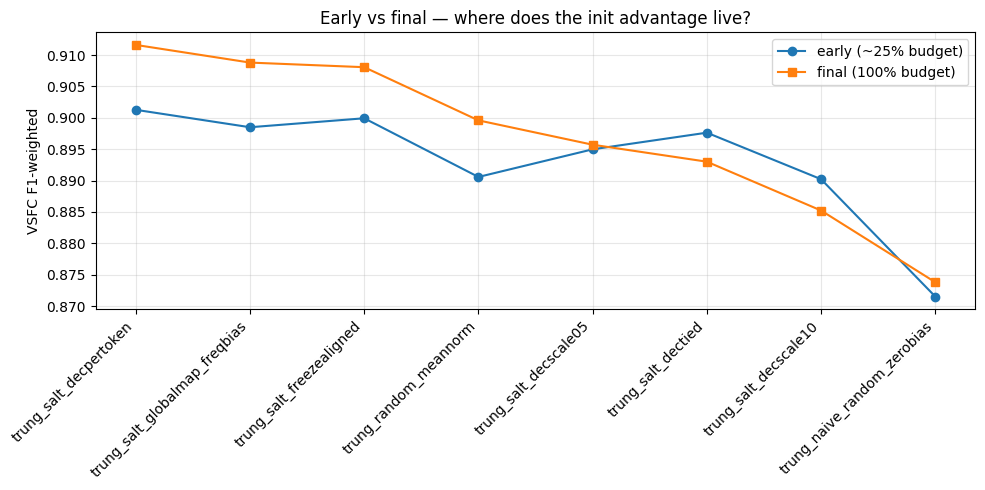

,arm,checkpoint,accuracy_mean,accuracy_std,f1_weighted_mean,f1_weighted_std
0,trung_naive_random_zerobias,early,0.876342,0.003350,0.871524,0.007338
1,trung_naive_random_zerobias,final,0.877606,0.002903,0.873809,0.007320
2,trung_random_meannorm,early,0.893872,0.001787,0.890581,0.001464
3,trung_random_meannorm,final,0.903506,0.002010,0.899597,0.001229
4,trung_salt_decpertoken,early,0.904769,0.003797,0.901280,0.004366
5,trung_salt_decpertoken,final,0.916930,0.001340,0.911621,0.002272
6,trung_salt_decscale05,early,0.898610,0.000000,0.894985,0.000898
7,trung_salt_decscale05,final,0.900032,0.007370,0.895717,0.006439
8,trung_salt_decscale10,early,0.894662,0.006030,0.890223,0.007840
9,trung_salt_decscale10,final,0.888977,0.006030,0.885234,0.007145


In [ ]:
agg = dp.summarize_sweet_spot(RESULTS_JSONL, COMPARE_DIR, random_arms=RANDOM_ARMS)
import pandas as pd
pd.set_option('display.width', 160)
agg

## 7. Harder tasks — rank the inits (ViANLI + MRC)

VSFC saturates (~0.91 for every good arm) so it can't separate the top inits. These two harder tasks
fine-tune the **already-saved `final_model` checkpoints** (no CPT rerun), 3 seeds:
- **ViANLI** — native Vietnamese NLI (sentence-pair, macro-F1). Cheap.
- **MRC-ViQuAD** — extractive QA (SQuAD EM/F1), the most discriminative probe. **The expensive part.**

> Runtime: ViANLI is modest; **MRC = 8 arms × 3 seeds QA fine-tunes** — tune `MRC_TRAIN_CAP` / `epochs` /
> `HARD_SEEDS`. Resumable: each `(task, arm, seed)` is skipped once recorded in `hardtask_results.jsonl`.
> MRC needs a fast tokenizer; the artifacts pin the slow DebertaV2 class but ship a fast `tokenizer.json`
> (with a `[CLS] A [SEP] B [SEP]` pair template), which `finetune_mrc` loads directly.

In [5]:
import salt3_downstream_mrc as mrc; importlib.reload(mrc); importlib.reload(dp)
HARD_RESULTS = RUNS_ROOT / 'hardtask_results.jsonl'
HARD_SEEDS   = [42, 123, 456]
# rebuild arm_results from disk so this section runs standalone after a kernel restart
arm_results = [{'arm': name,
                'final_dir': RUNS_ROOT / name / 'final_model',
                'early_dir':  RUNS_ROOT / name / 'early_25pct'} for name, _ in ARMS]
print('arms for hard tasks:', [a['arm'] for a in arm_results])

arms for hard tasks: ['trung_naive_random_zerobias', 'trung_random_meannorm', 'trung_salt_decpertoken', 'trung_salt_decscale05', 'trung_salt_decscale10', 'trung_salt_dectied', 'trung_salt_freezealigned', 'trung_salt_globalmap_freqbias']


In [6]:
vianli = dp.load_vianli()
print('ViANLI splits:', {k: len(v) for k, v in vianli.items()})
dp.run_seq_probe(arm_results, HARD_RESULTS, task='ViANLI', dataset=vianli, num_labels=3,
                 text_fields=('premise', 'hypothesis'), metric_for_best='f1_macro',
                 seeds=HARD_SEEDS, checkpoints=('final',), device=DEVICE,
                 lr=2e-5, max_epochs=6, batch_size=16, max_len=256, patience=2)

README.md:   0%|          | 0.00/2.29k [00:00<?, ?B/s]

vianli_train.jsonl:   0%|          | 0.00/2.89M [00:00<?, ?B/s]

vianli_dev.jsonl:   0%|          | 0.00/364k [00:00<?, ?B/s]

vianli_test.jsonl:   0%|          | 0.00/365k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8012 [00:00<?, ? examples/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro
1,1.113101,1.117367,0.333000,0.166375,0.166542
2,1.109839,1.105707,0.333000,0.166375,0.166542
3,1.121240,1.098109,0.341000,0.211851,0.212029
4,1.120215,1.094535,0.348000,0.211175,0.211257
5,1.067097,1.067164,0.417000,0.330187,0.330045
6,1.060459,1.066393,0.434000,0.348072,0.347890


[transformers] early stopping required metric_for_best_model, but did not find eval_f1_macro so early stopping is disabled


Training Loss,Validation Loss,Epoch,Accuracy,F1 Weighted,F1 Macro
1.060459,1.071023,6,0.430000,0.344765,0.344585


    -> {'task': 'ViANLI', 'arm': 'trung_salt_globalmap_freqbias', 'checkpoint': 'final', 'seed': 456, 'accuracy': 0.43, 'f1_weighted': 0.34476517181980093}


[{'task': 'ViANLI',
  'arm': 'trung_naive_random_zerobias',
  'checkpoint': 'final',
  'seed': 42,
  'accuracy': 0.333,
  'f1_weighted': 0.25823011931096573},
 {'task': 'ViANLI',
  'arm': 'trung_naive_random_zerobias',
  'checkpoint': 'final',
  'seed': 123,
  'accuracy': 0.336,
  'f1_weighted': 0.26665317329454075},
 {'task': 'ViANLI',
  'arm': 'trung_naive_random_zerobias',
  'checkpoint': 'final',
  'seed': 456,
  'accuracy': 0.389,
  'f1_weighted': 0.313816896008218},
 {'task': 'ViANLI',
  'arm': 'trung_random_meannorm',
  'checkpoint': 'final',
  'seed': 42,
  'accuracy': 0.376,
  'f1_weighted': 0.2992546217271807},
 {'task': 'ViANLI',
  'arm': 'trung_random_meannorm',
  'checkpoint': 'final',
  'seed': 123,
  'accuracy': 0.414,
  'f1_weighted': 0.37891380878472763},
 {'task': 'ViANLI',
  'arm': 'trung_random_meannorm',
  'checkpoint': 'final',
  'seed': 456,
  'accuracy': 0.401,
  'f1_weighted': 0.39765658114019814},
 {'task': 'ViANLI',
  'arm': 'trung_salt_decpertoken',
  'check

In [7]:
MRC_TRAIN_CAP = 8000     # per-arm QA train cap (shared across arms -> relative ranking); raise for cleaner separation
qa = mrc.load_viquad()
print('ViQuAD splits:', {k: len(v) for k, v in qa.items()})
mrc.run_mrc_probe(arm_results, qa, HARD_RESULTS, task='MRC-ViQuAD',
                  seeds=HARD_SEEDS, checkpoints=('final',), device=DEVICE,
                  train_cap=MRC_TRAIN_CAP, eval_cap=500, epochs=3, batch_size=8, max_len=384, lr=2e-5)

README.md:   0%|          | 0.00/6.04k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/5.20M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/735k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/28454 [00:00<?, ? examples/s]

...

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  QA rows: 500 kept, drops={'no_answer': 240, 'span_not_found': 0, 'truncated': 1}


Epoch,Training Loss,Validation Loss
1,1.865389,1.774619
2,1.157021,1.724055
3,0.495777,2.264855


    -> {'task': 'MRC-ViQuAD', 'arm': 'trung_salt_globalmap_freqbias', 'checkpoint': 'final', 'seed': 456, 'f1': 67.45616657982586, 'exact_match': 40.6}


[{'task': 'ViANLI',
  'arm': 'trung_naive_random_zerobias',
  'checkpoint': 'final',
  'seed': 42,
  'accuracy': 0.333,
  'f1_weighted': 0.25823011931096573},
 {'task': 'ViANLI',
  'arm': 'trung_naive_random_zerobias',
  'checkpoint': 'final',
  'seed': 123,
  'accuracy': 0.336,
  'f1_weighted': 0.26665317329454075},
 {'task': 'ViANLI',
  'arm': 'trung_naive_random_zerobias',
  'checkpoint': 'final',
  'seed': 456,
  'accuracy': 0.389,
  'f1_weighted': 0.313816896008218},
 {'task': 'ViANLI',
  'arm': 'trung_random_meannorm',
  'checkpoint': 'final',
  'seed': 42,
  'accuracy': 0.376,
  'f1_weighted': 0.2992546217271807},
 {'task': 'ViANLI',
  'arm': 'trung_random_meannorm',
  'checkpoint': 'final',
  'seed': 123,
  'accuracy': 0.414,
  'f1_weighted': 0.37891380878472763},
 {'task': 'ViANLI',
  'arm': 'trung_random_meannorm',
  'checkpoint': 'final',
  'seed': 456,
  'accuracy': 0.401,
  'f1_weighted': 0.39765658114019814},
 {'task': 'ViANLI',
  'arm': 'trung_salt_decpertoken',
  'check

In [ ]:
# Leaderboard straight from Drive — reads runs/bakeoff100k/hardtask_results.jsonl, NO retraining.
# Only needs the imports cell + "## 1. Configure" cell to have run (not the ViANLI/MRC cells).
HARD_RESULTS = RUNS_ROOT / 'hardtask_results.jsonl'
assert HARD_RESULTS.exists(), f'{HARD_RESULTS} not found on Drive — nothing to summarize'
print(f'loaded {len(dp.read_jsonl(HARD_RESULTS))} rows from {HARD_RESULTS}')
hard = dp.summarize_tasks(HARD_RESULTS, COMPARE_DIR,
                          task_metric={'ViANLI': 'f1_weighted', 'MRC-ViQuAD': 'f1'},
                          random_arms=RANDOM_ARMS)
hard

## 8. How to read the result (updated with the real @100k run)

**VSFC (cell 6) saturated** — every good arm ~0.90–0.91 F1; SALT-vs-best-random gap ≈ 1 pt, inside
2-seed noise. VSFC alone can't pick a winner; that's why §7 adds harder tasks.

**MLM loss ⊥ downstream.** The loss/PPL overlays (cell 5) rank the *decoder* init (decscale/tied land
at ppl 500–860, far worse than random's 32) — but downstream uses the [CLS] encoder rep + a fresh head,
so those same arms still score ~0.88 F1. Read the loss curves as a **decoder-init** story, not a
downstream proxy.

**What actually wins (final @100k):** the global-map / per-token SALT family — `decpertoken`, `globalmap`,
`freezealigned` — leads both MLM (ppl 20–23) and downstream; **per-token took #1 on VSFC**. The ViANLI +
MRC leaderboards (cell 7) are the tiebreaker — look at Δ-to-random there to confirm the winner.

**Sweet spot:** the good arms plateau on MLM by ~step 150 of 182 and early≈final downstream — i.e. 100k
is at/just past convergence for the strong inits. To show the resource-saving *curve*, probe the
low-budget regime: few-shot downstream (`train_cap` on the probe) and/or CPT snapshots before step 45.

In [ ]:
from google.colab import runtime
# Disconnect the runtime to stop charging compute units once done
runtime.unassign()